In [1]:
import os 
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from glob import glob
from anndata import AnnData
import matplotlib.pyplot as plt

In [2]:
sample_list = os.listdir("./../data/st_data/")
adatas_raw = dict() 
for sample in sample_list:
    adatas_raw[sample] = sc.read_h5ad("./../data/st_qc/{}.h5ad".format(sample))
    sc.pp.normalize_total(adatas_raw[sample])
    adatas_raw[sample].layers['scaled'] = np.sqrt(adatas_raw[sample].to_df())

In [3]:
for sample in sample_list:
    cellType_deconvolution = pd.read_csv("./results/{}.csv".format(sample), index_col = 0)
    print(cellType_deconvolution.shape)
    cellType_deconvolution.reset_index(inplace = True)
    cellType_deconvolution[['Sample', 'barcode']] = cellType_deconvolution['index'].str.split('_',  expand=True)
    cellType_deconvolution = cellType_deconvolution.drop("index", axis = 1)
    cellType_deconvolution.set_index("barcode", inplace = True)
    adatas_raw[sample].obs = pd.merge( adatas_raw[sample].obs, cellType_deconvolution, left_index= True, right_index = True)

(1800, 8)
(1934, 8)
(2937, 8)
(3004, 8)
(3629, 8)
(2121, 8)
(1504, 8)
(3180, 8)


In [4]:
cellType_annot_df = pd.DataFrame(columns = ["cell_type_annotations"])
asc_sample_list = ["GSM6506110_SP1", "GSM6506111_SP2", "GSM6506112_SP3", "GSM6506113_SP4", 
                   "GSM6506114_SP5", "GSM6506115_SP6", "GSM6506116_SP7", "GSM6506117_SP8"]
for sample in asc_sample_list:
    cellType_deconvolution = pd.read_csv("./results/{}.csv".format(sample), index_col = 0)
    #print(cellType_deconvolution.shape)
    sample_cellType_annot_df = pd.DataFrame(cellType_deconvolution.idxmax(axis=1), columns = ["cell_type_annotations"])
    #print(sample_cellType_annot_df.shape)
    cellType_annot_df = pd.concat([cellType_annot_df, sample_cellType_annot_df], axis = 0)
    print(cellType_annot_df.shape)

cellType_annot_df.head()

(2937, 1)
(4871, 1)
(6375, 1)
(9379, 1)
(11500, 1)
(13300, 1)
(16929, 1)
(20109, 1)


,cell_type_annotations
P1_AAACAAGTATCTCCCA-1,Tumour_cells
P1_AAACATTTCCCGGATT-1,Tumour_cells
P1_AAACCCGAACGAAATC-1,Tumour_cells
P1_AAACCGGGTAGGTACC-1,Tumour_cells
P1_AAACCGTTCGTCCAGG-1,Tumour_cells


In [5]:
cellType_annot_df.reset_index().to_csv("./results/rctd_cell_type_annotations.csv", index= False)

## Images

In [6]:
cell_types = ['Tumour_cells', 'Fibroblasts', 'Myofibroblasts', 'Macrophages', "B_Plasma_cells", "Endothelial_cells"]
sample_cell_types = {
    "GSM6506110_SP1": cell_types,
    "GSM6506111_SP2": cell_types,
    "GSM6506112_SP3": cell_types,
    "GSM6506113_SP4": cell_types,
    "GSM6506114_SP5": cell_types,
    "GSM6506115_SP6": cell_types,
    "GSM6506116_SP7": cell_types,
    "GSM6506117_SP8": cell_types
}

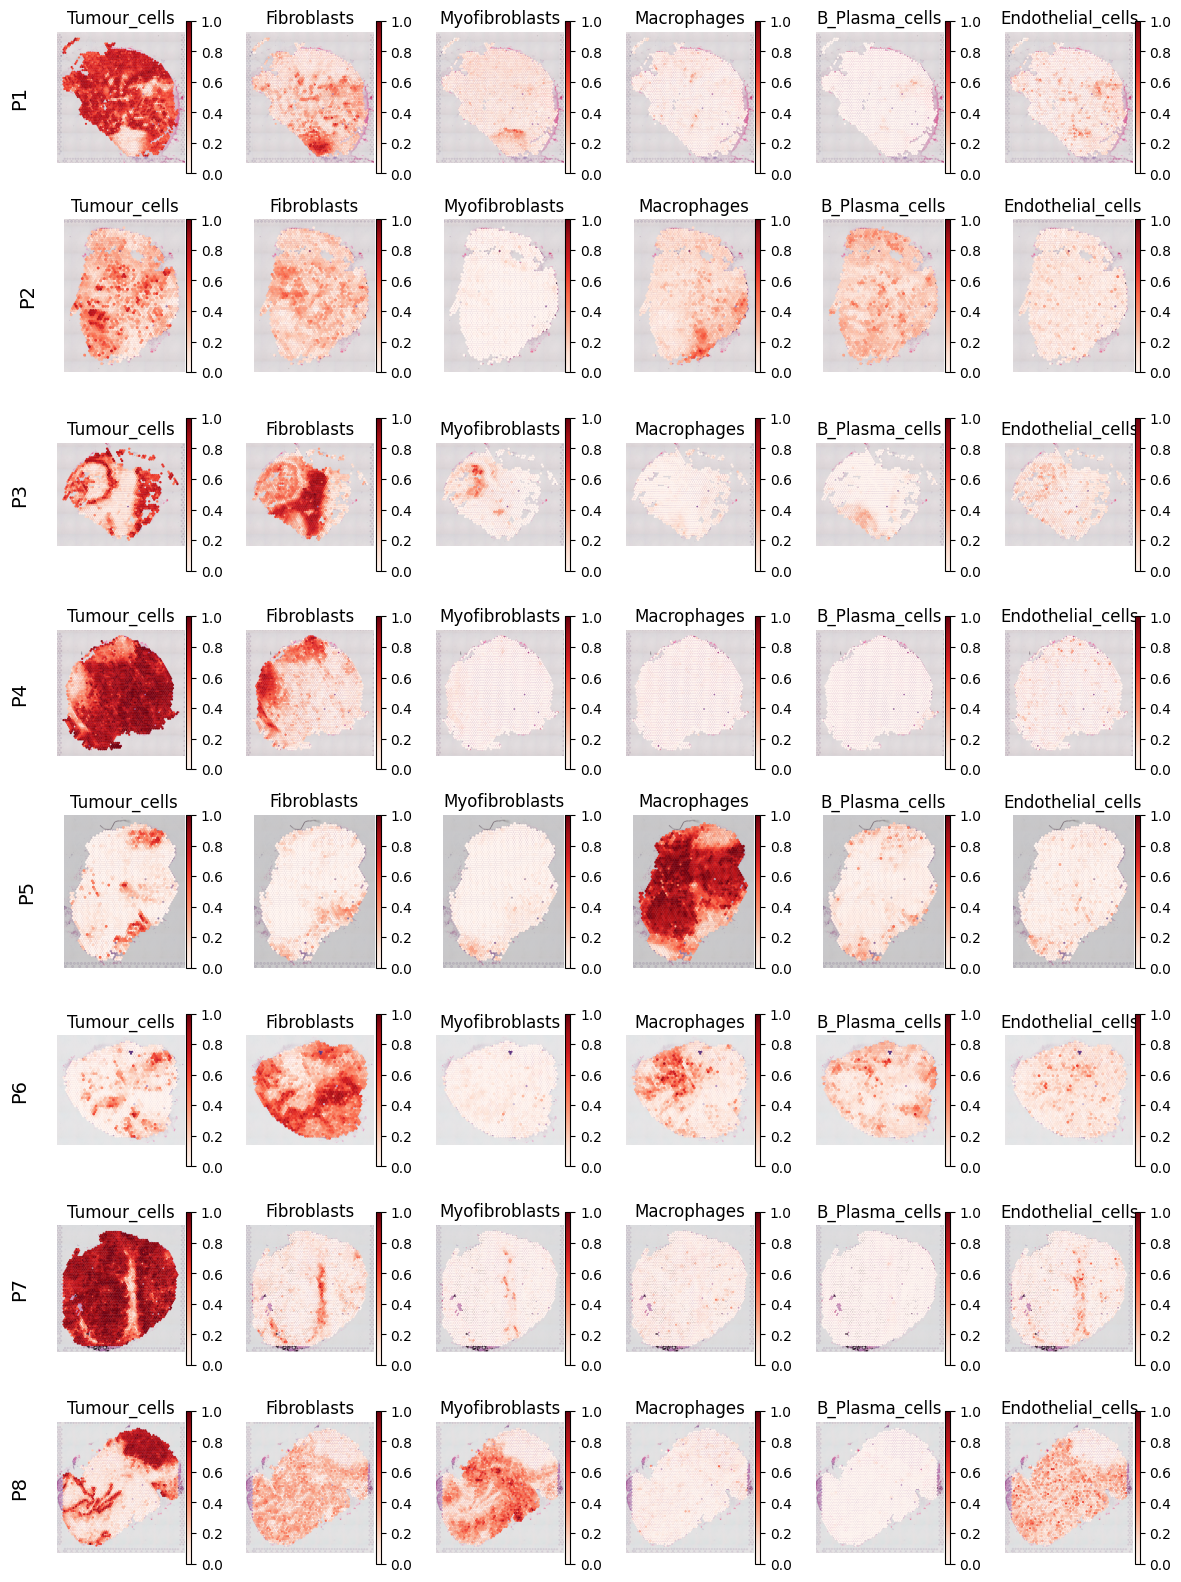

In [7]:
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(sample_list)
ncol = len(cell_types)
fig, axs = plt.subplots(nrow, ncol, figsize=(2 * ncol, 2 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (sample, cellTypes) in enumerate(sample_cell_types.items()):
    col_idx = 0
    for ct in cellTypes:
        ax = axs[row_idx, col_idx]
        sc.pl.spatial(adatas_raw[sample], color = ct, size = 1.8, cmap = "Reds", vmax= 1, vmin = 0,
                      ax = ax, show = False, frameon = False)

        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(sample[12:14] + "\n", rotation=90, fontsize=14)
            ax.set_xlabel("")
            ax.set(frame_on=False)
        col_idx += 1
        
# Alignment within the Figure
fig.tight_layout()
plt.savefig("./results/cell_type_deconvolution.png", dpi=300, bbox_inches='tight')